# 🌦️ Weather Forecast 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')

In [3]:
df = pd.read_csv(r"D:\user\Downloads\archive (1)\weather_forecast_data.csv")
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(10)

Shape: (2500, 6)
Columns: ['Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure', 'Rain']


,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain
5,26.147353,48.217260,15.258547,59.766279,1049.738751,no rain
6,20.939680,40.799444,2.232566,45.827508,1014.173766,no rain
7,32.294325,51.848471,2.873621,92.551497,1006.041733,no rain
8,34.091569,48.057114,5.570206,82.524873,993.732047,no rain
9,19.586038,82.978293,5.760537,98.014450,1036.503457,rain


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   object 
dtypes: float64(5), object(1)
memory usage: 117.3+ KB


In [5]:
df.describe().round(2)

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure
count,2500.00,2500.00,2500.00,2500.00,2500.00
mean,22.58,64.35,9.91,49.66,1014.31
std,7.33,19.95,5.78,29.12,20.20
min,10.00,30.01,0.01,0.02,980.01
25%,16.36,47.34,4.76,23.90,996.94
50%,22.54,63.92,9.91,49.49,1013.43
75%,28.98,81.56,14.95,75.32,1031.74
max,35.00,100.00,20.00,100.00,1049.99


In [6]:
print(df.isnull().sum())

Temperature    0
Humidity       0
Wind_Speed     0
Cloud_Cover    0
Pressure       0
Rain           0
dtype: int64


In [7]:
df.duplicated().sum()

0

In [8]:
print('Rain value counts:')
print(df['Rain'].value_counts())

Rain value counts:
Rain
no rain    2186
rain        314
Name: count, dtype: int64


In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Rain_binary'] = le.fit_transform(df['Rain'])

In [10]:
df.head(5)

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain,Rain_binary
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain,1
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain,0
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain,0
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain,1
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain,0


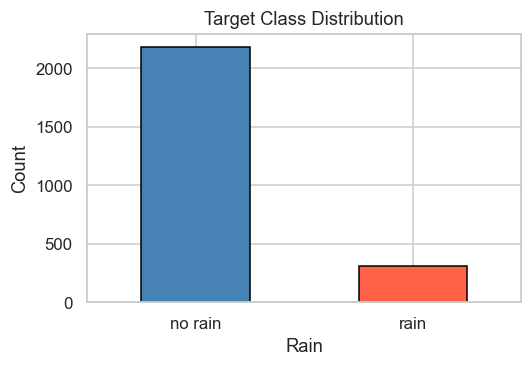

In [11]:
fig, ax = plt.subplots(figsize=(5, 3.5))
df['Rain'].value_counts().plot(kind='bar', ax=ax, color=['steelblue','tomato'], edgecolor='black')
ax.set_title('Target Class Distribution')
ax.set_xlabel('Rain')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

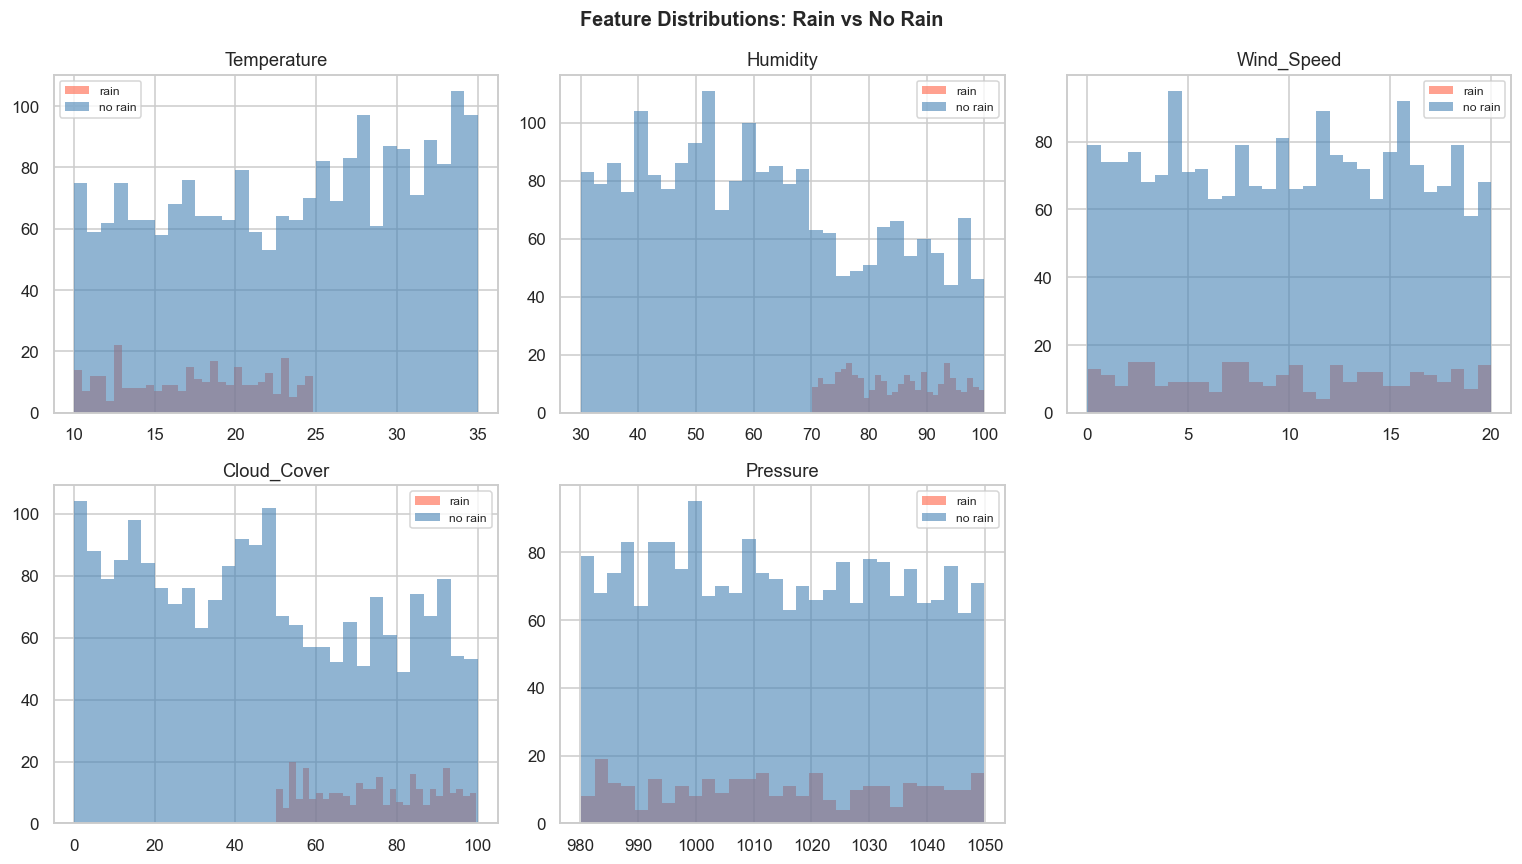

In [12]:
features = ['Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    for label, color in [('rain', 'tomato'), ('no rain', 'steelblue')]:
        subset = df[df['Rain'] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='none')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)   # hide empty 6th subplot
fig.suptitle('Feature Distributions: Rain vs No Rain', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

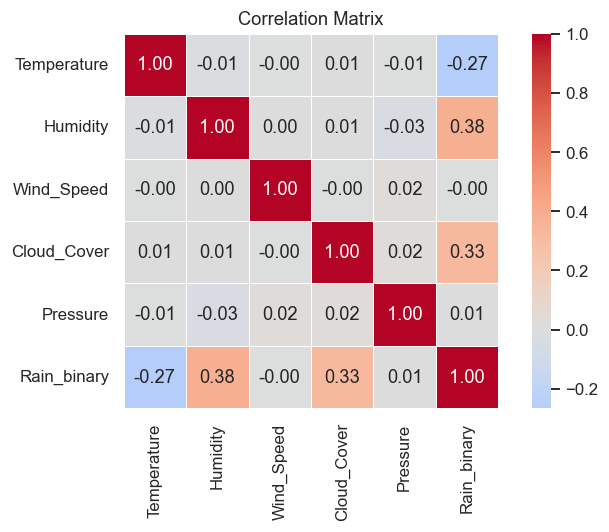

In [13]:
corr = df[features + ['Rain_binary']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [14]:
FEATURE_COLS = ['Temperature', 'Humidity', 'Wind_Speed',
                'Cloud_Cover', 'Pressure']
TARGET = 'Rain_binary'

X = df[FEATURE_COLS]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set : {X_train.shape[0]} rows')
print(f'Test set     : {X_test.shape[0]} rows')

Training set : 2000 rows
Test set     : 500 rows


In [15]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [16]:
lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
lr.fit(X_train_sc, y_train)
print('Logistic Regression trained')

Logistic Regression trained


In [17]:
from sklearn.svm import SVC
svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm.fit(X_train_sc, y_train)  
print('SVM trained')

SVM trained


In [18]:
def evaluate_model(name, model, X_test_input, y_test):
    y_pred  = model.predict(X_test_input)
    y_proba = model.predict_proba(X_test_input)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)

    print(f'  {name}')
    print(f'  ROC-AUC : {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['No Rain','Rain']))
    return y_pred, y_proba, auc

lr_pred, lr_proba, lr_auc = evaluate_model('Logistic Regression', lr, X_test_sc, y_test)
print('-------------------------------------------------------')
svm_pred, svm_proba, svm_auc = evaluate_model('SVM (RBF)', svm, X_test_sc, y_test)

  Logistic Regression
  ROC-AUC : 0.9643
              precision    recall  f1-score   support

     No Rain       0.99      0.88      0.93       437
        Rain       0.53      0.95      0.68        63

    accuracy                           0.89       500
   macro avg       0.76      0.91      0.80       500
weighted avg       0.93      0.89      0.90       500

-------------------------------------------------------
  SVM (RBF)
  ROC-AUC : 0.9958
              precision    recall  f1-score   support

     No Rain       1.00      0.92      0.96       437
        Rain       0.64      0.98      0.78        63

    accuracy                           0.93       500
   macro avg       0.82      0.95      0.87       500
weighted avg       0.95      0.93      0.93       500



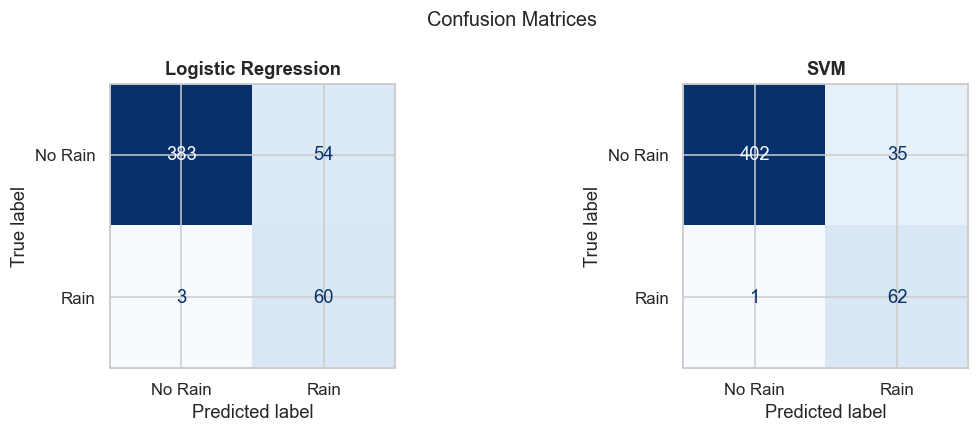

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, pred, title in zip(axes,
                           [lr_pred, svm_pred],
                           ['Logistic Regression', 'SVM']):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Rain', 'Rain'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.show()

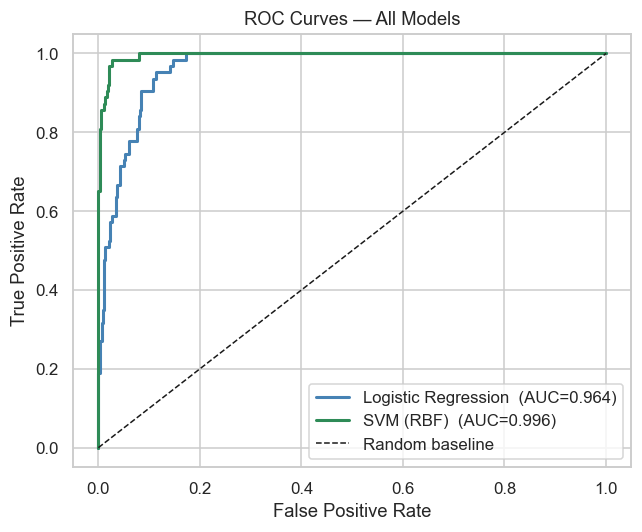

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))

for proba, auc, label, color in [
    (lr_proba,  lr_auc,  'Logistic Regression', 'steelblue'),
    (svm_proba, svm_auc, 'SVM (RBF)',             'seagreen')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f'{label}  (AUC={auc:.3f})', lw=2, color=color)

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend()
plt.tight_layout()
plt.show()

In [41]:
import pickle
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Model saved')

Model saved
